# Análisis exploratoriode los datos

El Análisis Exploratorio de Datos (EDA, por sus siglas en inglés) es parte del proceso inicial de comprensión de los datos, y es esencial en cualquier proyecto de análisis de datos, sin importar los objetivos de este. El propósito de un análisis exploratorio es comprender la estructura de los datos, identificar patrones, detectar anomalías y extraer información clave antes de aplicar modelos o realizar interpretaciones más profundas.

Vamos a hacer un ejercicio práctico de EDA.

## Paso 1: Carga y comprensión de los datos

Antes de cargar los datos en Python es conveniente **verlos** en bloc de notas o  en Excel.

Vamos a trabajar con el dataset **adult.data**, cuyo diccionario de datos se puede consultar en la página de [UC Irvine](https://archive.ics.uci.edu/dataset/2/adult).

In [ ]:
import pandas as pd

df = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'],
    na_values=[' ?', ' ']
)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Con el método `info()` podemos responder las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Con `describe()` y `unique()` podemos empezar el proceso de exploración, respondiendo las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Cuáles son claves primarias o identificadores únicos?
- ¿Hay formatos no estandarizados (fechas, monedas, mayúsculas/minúsculas)?


In [4]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [6]:
for col in df.select_dtypes(include=["object"]).columns:
    print(f'La columna "{col}" tiene las siguientes categorías: \n {df[col].unique()} \n')

La columna "workclass" tiene las siguientes categorías: 
 [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 nan ' Self-emp-inc' ' Without-pay' ' Never-worked'] 

La columna "education" tiene las siguientes categorías: 
 [' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th'] 

La columna "marital-status" tiene las siguientes categorías: 
 [' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed'] 

La columna "occupation" tiene las siguientes categorías: 
 [' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' nan
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv'] 

La columna "relationship" tiene las siguientes categorías: 
 [

También se deben responder las siguientes preguntas:

- ¿Qué columnas tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?

In [7]:
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

,0
occupation,5.660146
workclass,5.638647
native-country,1.790486
fnlwgt,0.000000
education,0.000000
education-num,0.000000
age,0.000000
marital-status,0.000000
relationship,0.000000
sex,0.000000


In [8]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  24


## Paso 2: Análisis univariado

### Variables cuantitativas y verificación del supuesto de normalidad

Muchos métodos de análisis estadísticos (los clásicos) se basan en el supuesto de que las variables cuantitativas a analizar tienen distribución normal o gaussiana. Este supuesto se puede verificar analizando los histogramas o los gráficos de densidad de las variables:

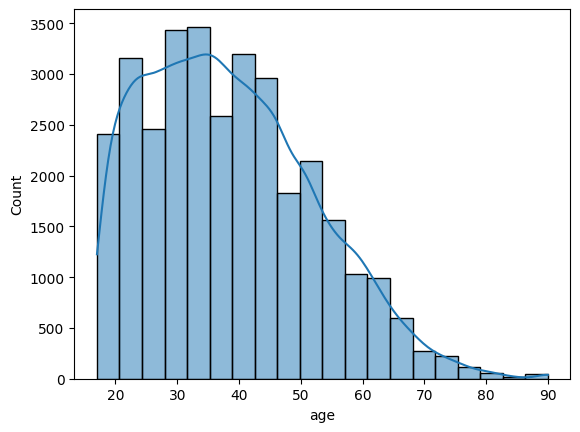

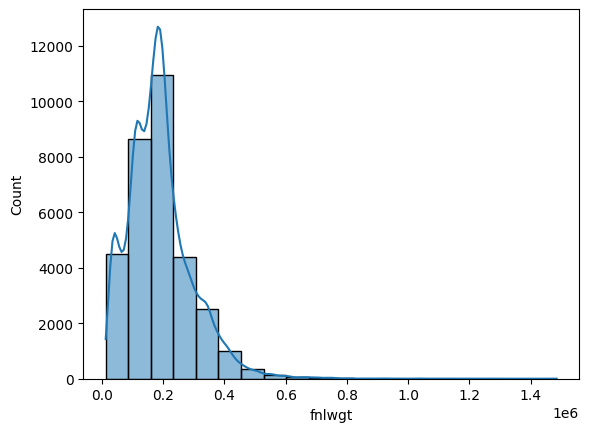

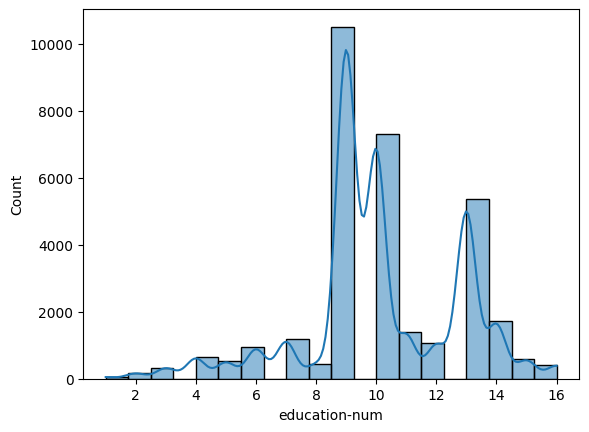

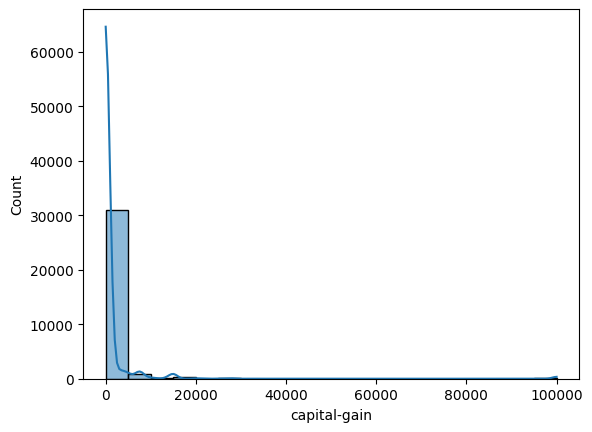

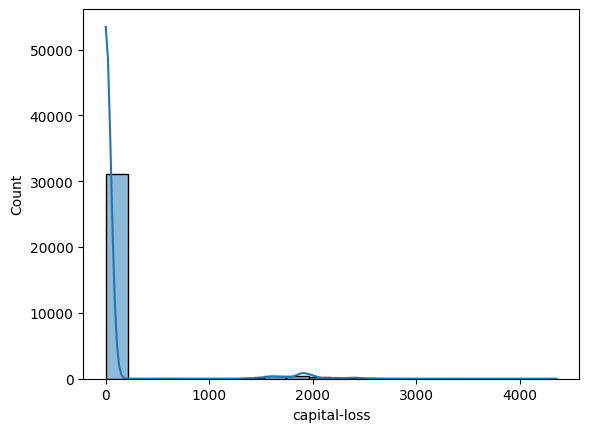

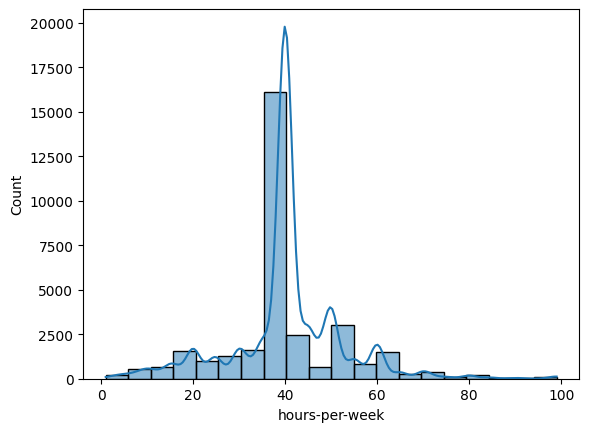

In [9]:
for col in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.show();

¿Qué observamos en este caso?

También se puede evaluar si las variables cumplen con el supuesto estadístico de normalidad midiendo la [curtosis](https://en.wikipedia.org/wiki/Kurtosis) y la [asimetría](https://en.wikipedia.org/wiki/Skewness) de su distribución. En Pandas es posible hacer esto con las funciones `kurt()`y `skew()`.

La **asimetría** (también conocida como **sesgo**) es una medida estadística que indica el grado de **simetría** de una distribución de datos respecto a su media. En otras palabras, muestra si los datos están más concentrados hacia un lado de la media que hacia el otro. De acuerdo con esto, las variables puden tener:

1. **Asimetría positiva (sesgo a la derecha)**  
   - Valor de asimetría > 0  
   - La cola derecha (valores grandes) es más larga o más pesada.  
   - La mayoría de los datos están concentrados en el lado izquierdo de la media.  
   - Ejemplo: ingresos personales (muchos ganan poco, pocos ganan mucho).

2. **Asimetría negativa (sesgo a la izquierda)**  
   - Valor de asimetría < 0  
   - La cola izquierda (valores pequeños) es más larga o más pesada.  
   - La mayoría de los datos están concentrados en el lado derecho de la media.  
   - Ejemplo: edad de jubilación (la mayoría se jubila a una edad similar, pocos lo hacen muy temprano).

3. **Asimetría nula (simétrica)**  
   - Valor de asimetría ≈ 0  
   - La distribución es simétrica respecto a la media.  
   - Ejemplo: distribución normal.

In [10]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetría de {num}: {df[num].skew():.3f} \n")

Asimetría de age: 0.559 

Asimetría de fnlwgt: 1.447 

Asimetría de education-num: -0.312 

Asimetría de capital-gain: 11.954 

Asimetría de capital-loss: 4.595 

Asimetría de hours-per-week: 0.228 



¿Qué podemos concluir de estos resultados?

Por otra parte, la **curtosis** es una medida estadística que describe la forma de una distribución, específicamente el grado de concentración de los datos en las colas (extremos) en comparación con una distribución normal. En términos de esta medida podemos hablar de 3 situaciones:

1. **Curtosis normal (mesocúrtica)**
   - Valor de curtosis ≈ 0.
   - La distribución tiene colas similares a las de una distribución normal.
   - Ejemplo: distribución normal estándar.

2. **Curtosis alta (leptocúrtica)**  
   - Valor de curtosis > 0.
   - La distribución tiene colas más pesadas y un pico más alto en el centro.
   - Indica mayor probabilidad de valores extremos (outliers).
   - Ejemplo: distribución t de Student con pocos grados de libertad.

3. **Curtosis baja (platicúrtica)**  
   - Valor de curtosis < 0.
   - La distribución es más plana, con colas más ligeras.
   - Menor probabilidad de valores extremos.
   - Ejemplo: distribución uniforme.

In [11]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Kurtosis de {num}: {df[num].kurt():.3f} \n")

Kurtosis de age: -0.166 

Kurtosis de fnlwgt: 6.219 

Kurtosis de education-num: 0.623 

Kurtosis de capital-gain: 154.799 

Kurtosis de capital-loss: 20.377 

Kurtosis de hours-per-week: 2.917 



¿Qué podemos concluir de estos resultados?

### Identification of outliers

Los *outliers* son valores atípicos en la muestra. Los *outliers* causan problemas cuando se construyen modelos predictivos, tales como tiempos de entrenamiento más largos, pobre desempeño, e incremento en la varianza del modelo, por lo que es recomendable eliminarlos antes de construir los modelos.

Existen 2 tipos de *outliers*: los univariados que se pueden detectar viendo las distribuciones de los datos mediantes histogramas, o mediante [diagramas de cajas](https://es.wikipedia.org/wiki/Diagrama_de_caja); y los multivariados, que solo se detectan analizando varias variables simultáneamente. Por ahora nos vamos a centrar en los *outliers* univariados.

En un *boxplot*, los puntos por fuera de los bigotes son valores atípicos.

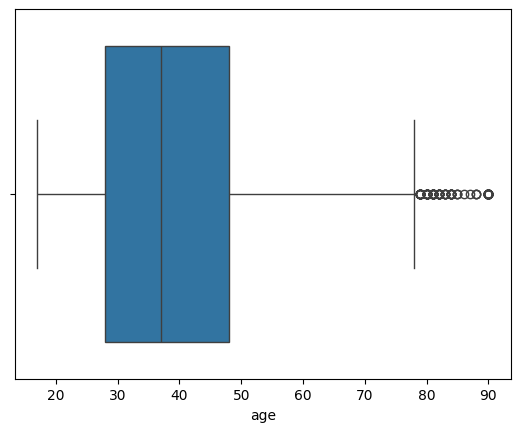

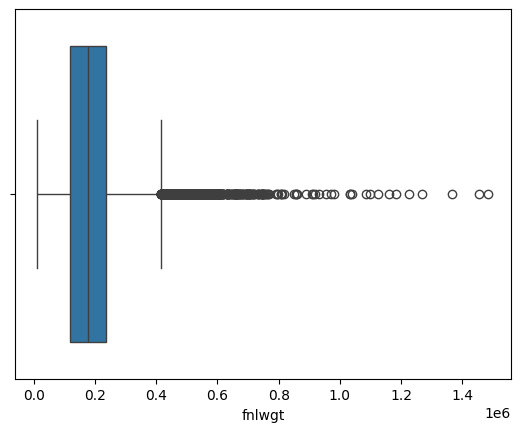

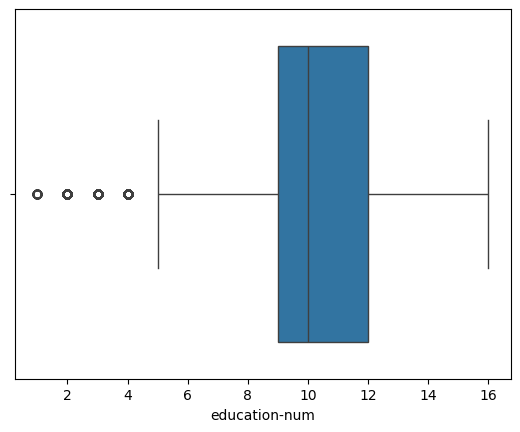

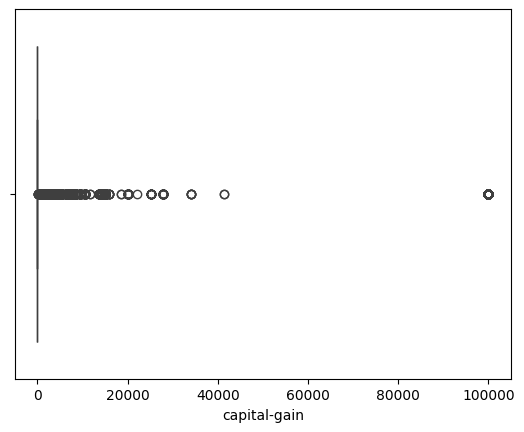

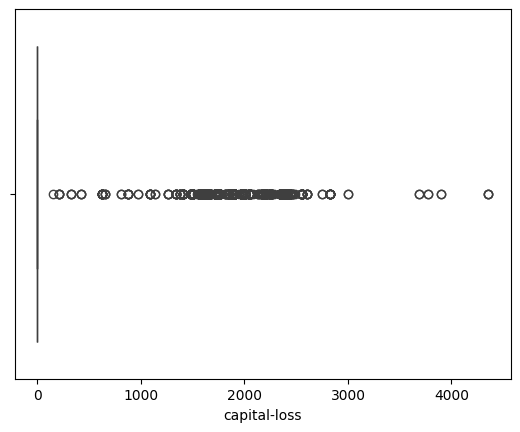

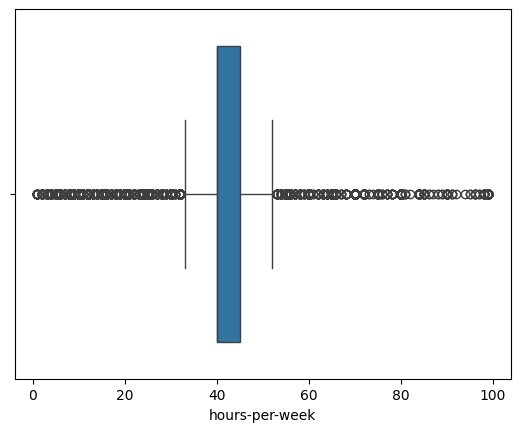

In [12]:
for num in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.boxplot(data=df, x=num)
    plt.show();

### Variables categóricas o cualitativas

En este caso se deben responder las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

Con el método `count_values()` podemos conocer la distribución de estas variables:

In [13]:
cat_vars = df.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable workclass es: 
 workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64 

El conteo de la variable education es: 
 education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64 

El conteo de la variable marital-status es: 
 marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name

Los **diagramas de barras** también nos dan una buena idea de la distribución de las variables categóricas:

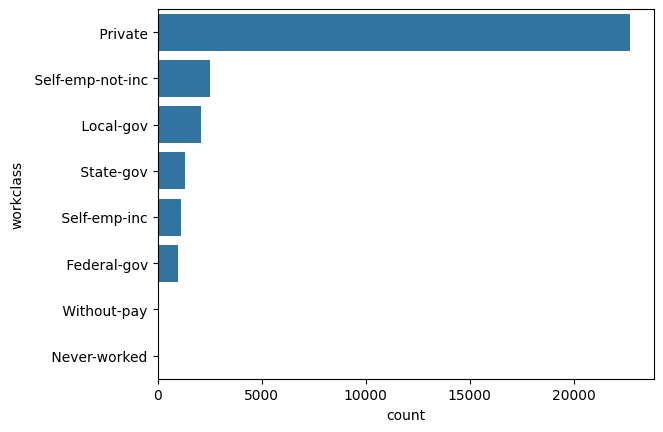

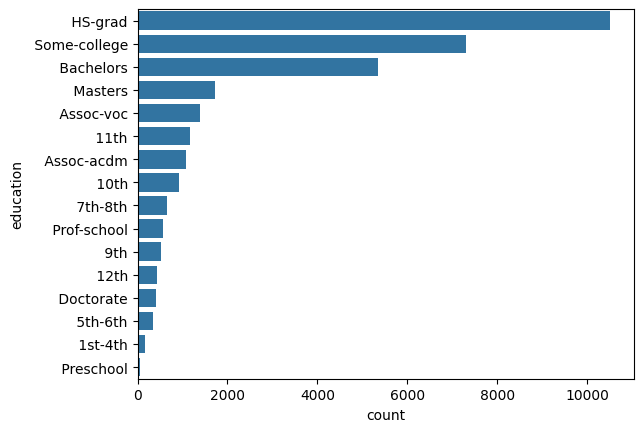

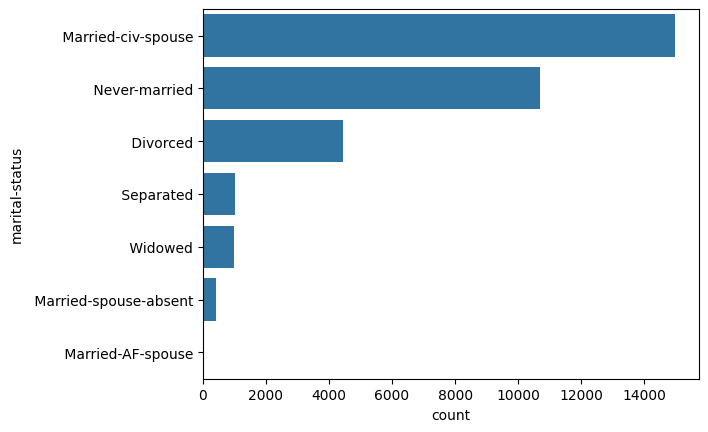

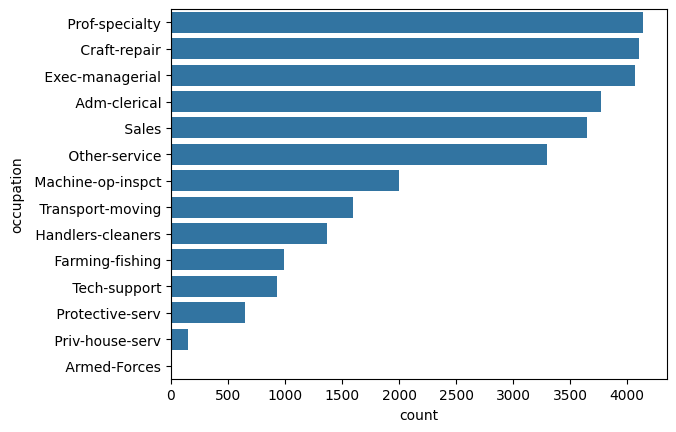

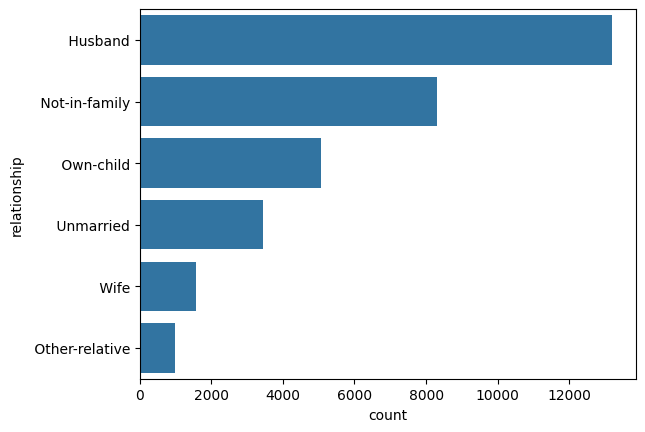

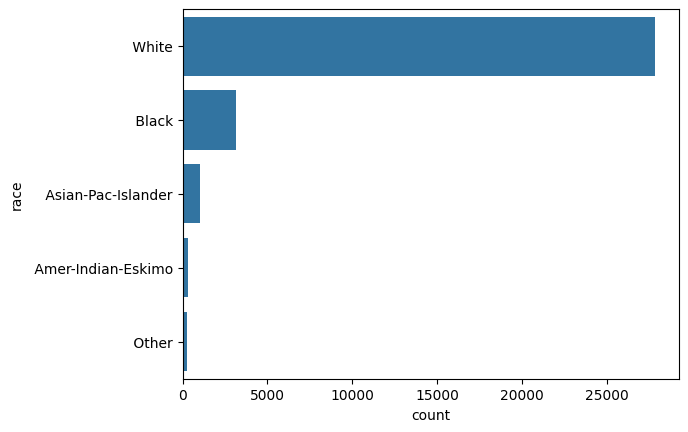

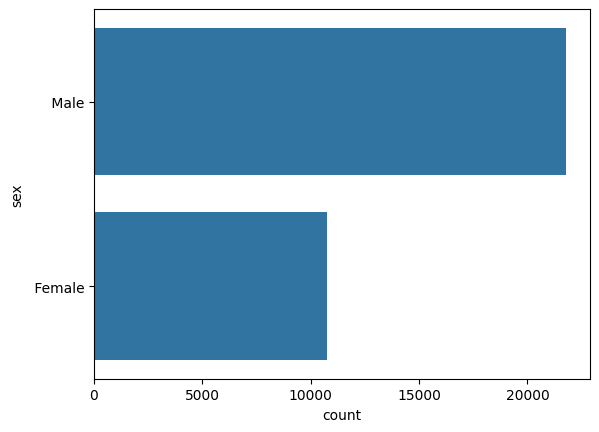

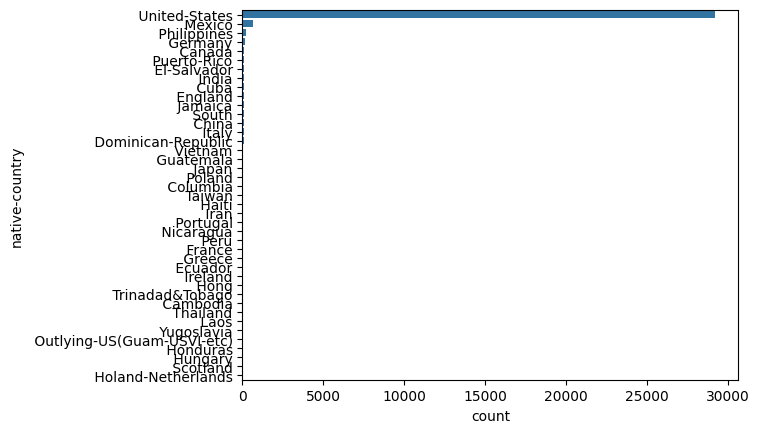

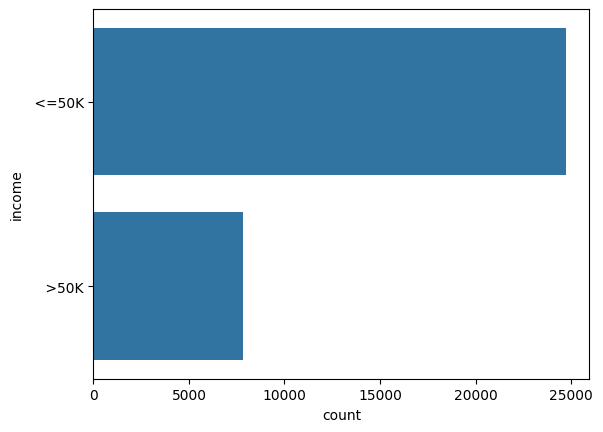

In [14]:
for cat in df.select_dtypes(include=['object']).columns:
    plt.figure()
    sns.countplot(data=df, y=cat, order=df[cat].value_counts().index)
    plt.show();

¿En este caso qué variables tienen alta cardinalidad? ¿Qué variables tienen categprías atípicas?

## Paso 4: Análisis multivariado

Los análisis univariados nos dan información sobre cada variable por separado, pero los datos rara vez existen de forma aislada. Las relaciones entre variables son clave para:

1. Identificar correlaciones y dependencias: ¿Cómo se relacionan dos variables numéricas? (ej. precio vs. tamaño) ¿Hay multicolinealidad que afecte modelos predictivos?
2. Detectar patrones y tendencias: ¿el ingreso promedio varía según el nivel educativo y la edad?
3. Encontrar interacciones y segmentaciones: Útil para segmentar clientes, entender perfiles o clasificar comportamientos.
4. Prevenir interpretaciones erróneas: Una variable puede parecer importante sola, pero perder relevancia al considerar otras.

En resumen, el análisis multivariado permite entender la estructura y relaciones en el conjunto de datos, no solo en variables aisladas.

### Relationships between two numerical variables:

Las relaciones entre variables numéricas se pueden **observar** mediante gráficos de dispersión, o medir mediante la función de correlación.

Por ejemplo, veamos si hay alguna relación entre las variables **age** y **hours-per-week**:

<Axes: xlabel='age', ylabel='hours-per-week'>

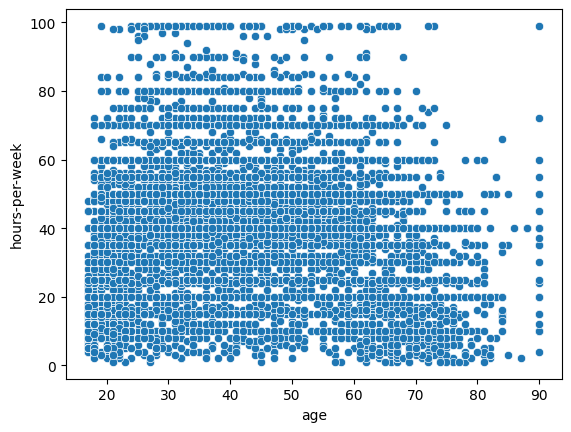

In [15]:
sns.scatterplot(data=df, x='age', y='hours-per-week')

¿Qué se observa?

En Seaborn, la función `pairplot()`permite generar los gráficos de dispersión de todos los pares de variables cuantitativas:

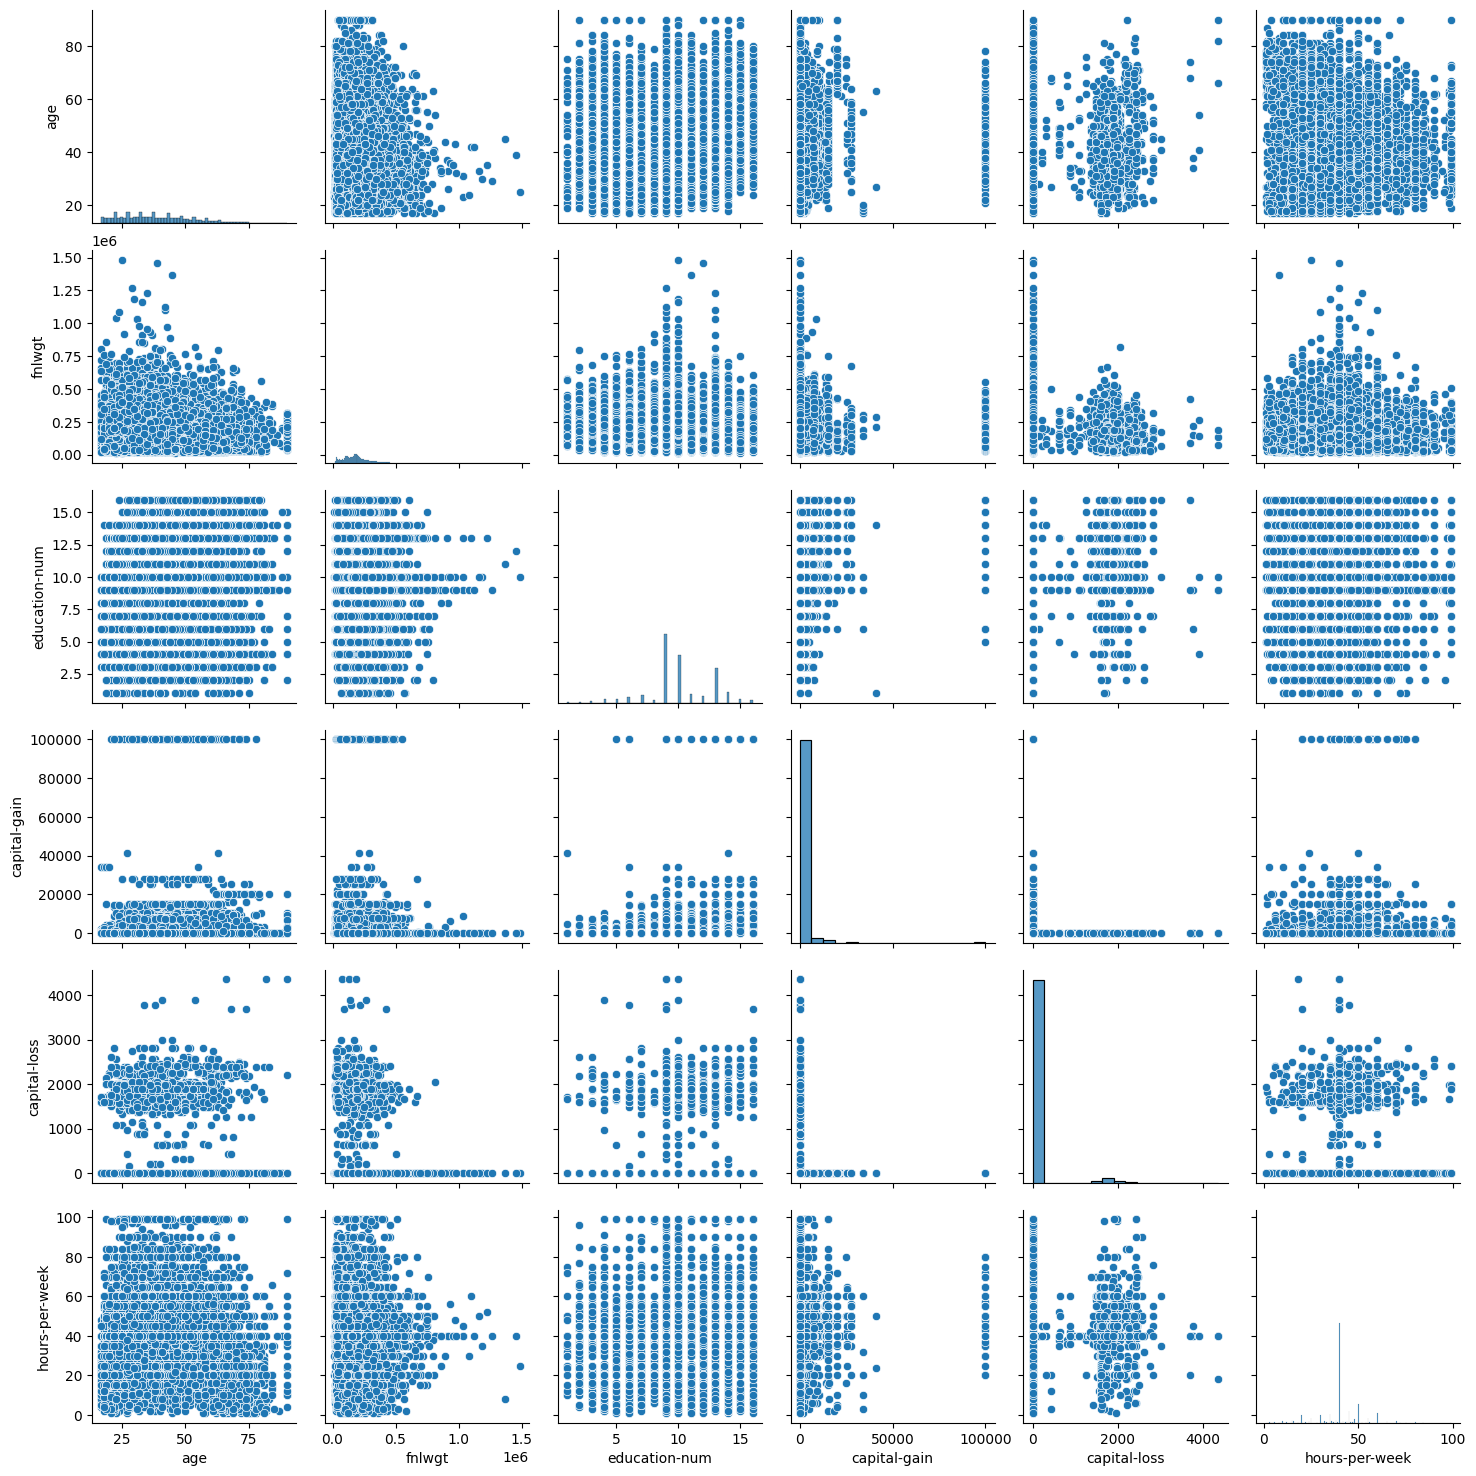

In [16]:
sns.pairplot(df.select_dtypes(include=['number']))

¿Se observa alguna relación interesante entre variables cuantitativas?

Por otra parte, la **función de correlación** mide el grado de relación entre dos variables, indicando cómo una variable cambia en función de otra. Se utiliza ampliamente en estadística y análisis de señales para identificar patrones y dependencias entre datos. En términos matemáticos, la correlación se calcula como la normalización de la covarianza, lo que permite obtener valores entre **-1 y 1**: un valor cercano a **1** indica una correlación positiva fuerte (ambas variables aumentan o disminuyen juntas), un valor cercano a **-1** indica una correlación negativa fuerte (una variable aumenta mientras la otra disminuye), y un valor cercano a **0** sugiere que no hay una relación lineal entre ellas. En aplicaciones como el análisis de datos, series temporales y procesamiento de señales, la función de correlación ayuda a detectar patrones ocultos, evaluar redundancia de datos y seleccionar variables relevantes para modelos predictivos.

In [18]:
df.select_dtypes('number').corr()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education-num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital-gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital-loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours-per-week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


Las correlaciones entre variables se interpretan mejor usando **mapas de calor**:

<Axes: >

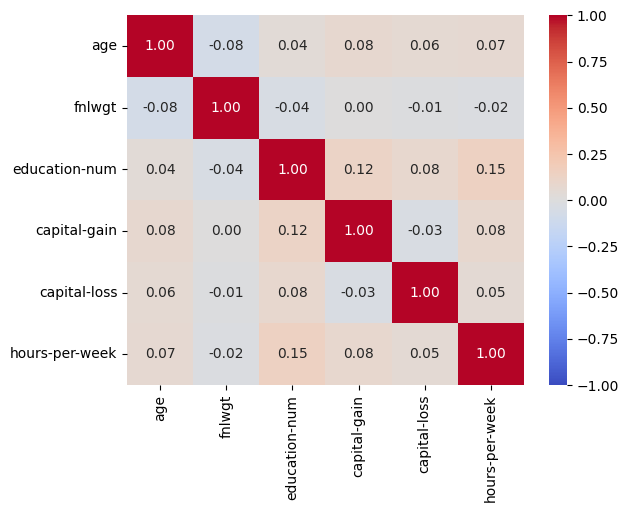

In [19]:
corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

¿Qué se observa?

### Relaciones entre una variable cuantitativa y otra cualitativa

En este caso, lo que se intenta encontrar es si el comportamiento de la variable numérica **depende** de las categorías de la variable categórica, esto es, sí se observan diferencias entre categorías.

Este tipo de análisis se suele hacer utilizando gráficos de cajas agrupados, histogramas o gráficos de densidad agrupados, o analizando las estadísticas descriptivas de la variable numérica **agrupada** por categorías de la variable categórica, usando la función `groupby()`.

Por ejemplo, vamos a evaluar si la variable **hours-per-week** depende de **income**:

<Axes: xlabel='hours-per-week', ylabel='income'>

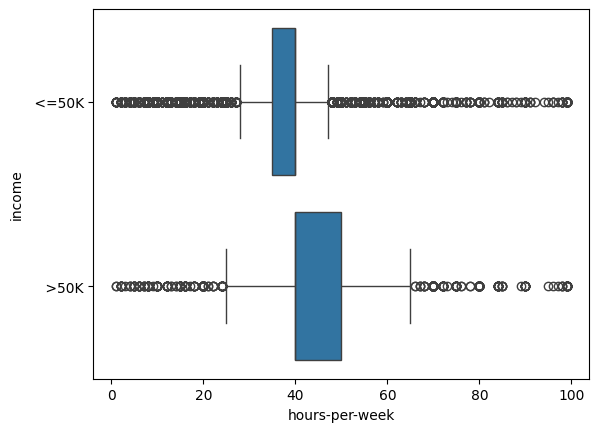

In [20]:
sns.boxplot(data=df, y='income', x='hours-per-week')

In [21]:
df.groupby('income')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,24720.0,36.783738,14.020088,17.0,25.0,34.0,46.0,90.0
>50K,7841.0,44.249841,10.519028,19.0,36.0,44.0,51.0,90.0


¿Qué se observa?

### Relaciones entre variables categóricas

Los análisis entre variables categóricas se pueden hacer usando tablas de contingencia, mapas de calor, o gráficos de barras agrupados o apilados, preferiblemente en proporciones.

Las tablas de contingencia muestran la distribución **conjunta** de dos o más variables categóricas. En **Pandas** se pueden hacer mediante la función `crosstab()`:

In [22]:
tabla = pd.crosstab(df['sex'], df['income'])
tabla

income,<=50K,>50K
sex,,
Female,9592,1179
Male,15128,6662


Estas tablas se pueden normalizar para ver las **proporciones**:

In [23]:
tabla = pd.crosstab(df['sex'], df['income'], normalize='index')
tabla

income,<=50K,>50K
sex,,
Female,0.890539,0.109461
Male,0.694263,0.305737


In [24]:
tabla = pd.crosstab(df['sex'], df['income'], normalize='columns')
tabla

income,<=50K,>50K
sex,,
Female,0.388026,0.150363
Male,0.611974,0.849637


In [25]:
tabla = pd.crosstab(df['sex'], df['income'], normalize='all')
tabla

income,<=50K,>50K
sex,,
Female,0.294586,0.036209
Male,0.464605,0.204601


Se pueden usar mapas de calor para visualizar las tablas de contingencia:

<Axes: xlabel='income', ylabel='sex'>

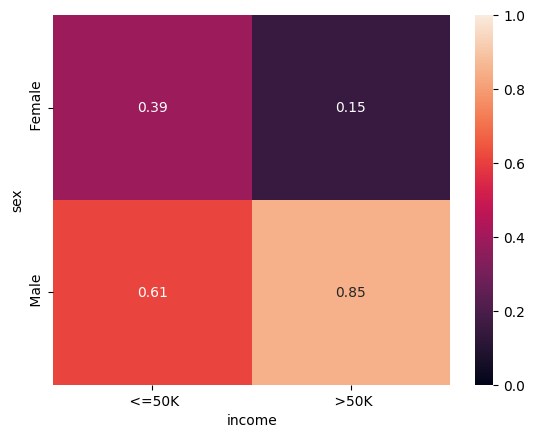

In [26]:
tabla = pd.crosstab(df['sex'], df['income'], normalize='columns')
sns.heatmap(tabla, annot=True, fmt='.2f', vmin=0, vmax=1)

Por último, se pueden usar gráficos de barras apilados o agrupados:

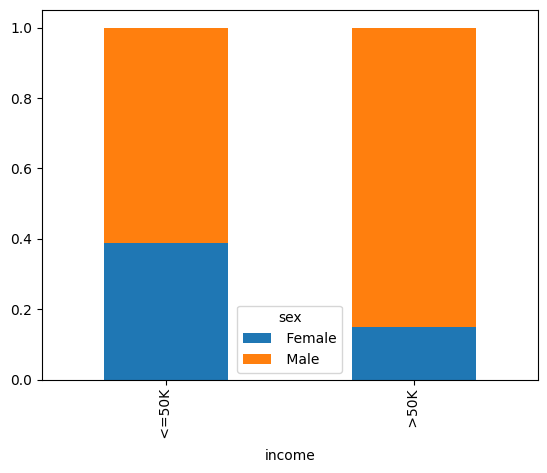

In [27]:
tabla = pd.crosstab(df['income'], df['sex'], normalize='index')
tabla.plot.bar(stacked=True);

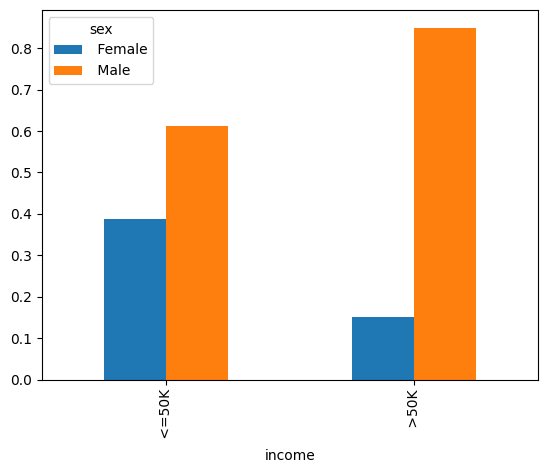

In [28]:
tabla.plot.bar(stacked=False);

¿Qué se observa?

# Ejercicio

Haga un EDA al archivo "Telco_customer_churn.csv", asumiendo que este dataset se va a utilizar para hacer un modelo predictivo que prediga si un cliente se va a retirar o no.